# Learned controllers: what a battery gets from imitation and reinforcement

`CODE.ipynb` asks what a **forecast** buys a home battery, answered with rules and
with a receding-horizon MILP. This notebook adds the third family — controllers
that **learn** the dispatch rather than being told it — and prices them through
exactly the same settlement:

| | what it is | what it needs at run time |
|---|---|---|
| **IL** `bc` | behaviour cloning of the whole-period MILP, solved over the *training* period | one forward pass |
| **RL** `dqn` | Double DQN, dueling head, rewarded by the arm's own settlement | one forward pass |
| **IL+RL** `bc_dqn` | the clone, then fine-tuned by the DQN under a BC regulariser | one forward pass |

All three are `Rule_Based_Control.Policy` subclasses, executed by `run_policy`
through the arm's `settle` with the endogenous SI contract converged — so a
learned row and a rule row differ **only** in how a setpoint is chosen. Training
only ever sees the 730-day training period; the scored year is untouched until
evaluation.

### Everything here is NET OF WEAR

The study's own axis, and not a detail. These controllers cycle roughly twice as
hard as self-consumption (166 EFC/a against 72 on AU), so a gross saving
flatters them by 40–70 EUR/a — and on SI by more than the whole saving. Every
figure below prices the cycles at what the pack costs, exactly as
`hems_study.summarize` does for the rules and the MILP arms. Where the gross and
net readings disagree, the text says so.

### What the screen covers

1260 runs: 30 households × 2 tariffs × 7 observation contracts × 3 methods,
plus 40 re-trained at double budget. Produced by

```bash
python3 run_rl_benchmark.py --ids <30 study units> --methods dqn bc bc_dqn --jobs 12
python3 run_rl_benchmark.py --retrain-unconverged --steps 1000000 --jobs 12
```

Nothing here re-trains or re-solves. The ranking reads the study's own frame
with the two deployable learned controllers joined on by
`hems_study.merge_learned_controllers`; the ablations read
`results_local/rl_screen/`. A few seconds cold.

### The observation contracts (`variant`)

`nofc` no load/PV forecast at all · `fc_h6` / `fc_h12` / `fc_h24` a **causal**
trailing-median forecast with 6/12/24 h of lookahead · `loadfc_pvtruth_h24`
perfect roof on a real load model · `truth_h24` perfect everything ·
`fc_h24_noprice` (AU) blind to the price · `fc_h24_nopeak` (SI) blind to the
contract and the running peak. The last two are the **"what data does this
tariff actually need"** ablations. `truth_h24` is a diagnostic, exactly like
`price_oracle` — never a deployable claim.

> **On hyperparameters.** These were **not** tuned by a search — see §6. Treat
> every number here as an *untuned baseline*.

In [1]:
import importlib, json
from pathlib import Path

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from matplotlib.lines import Line2D

import hems_study as hs
import figure_style as fs
import run_rl_benchmark as rb
import Battery_Economics as be
hs, fs, rb = (importlib.reload(m) for m in (hs, fs, rb))

import Plotting_Functions as pf
pf = importlib.reload(pf)
pf.use(subdir="hems", titles=False)
from Plotting_Functions import INK, INK_2, MUTED, SURFACE, SERIES, EUR, PLAIN, finish

# The deployable observation contract: a causal day-ahead forecast on both
# channels, 24 h of lookahead. `truth_h24` is a diagnostic -- like
# `price_oracle` -- and appears only where foresight IS the question.
DEPLOYABLE = "fc_h24"

# ---- (a) the study's own frame, with the learned controllers joined on ----
# This is the authoritative ranking: `summarize` prices every controller the
# same way, NET OF WEAR, and the learned rows go through it unchanged.
df_all = hs.merge_learned_controllers(
    hs.collect_results(arms=list(hs.REFERENCE_ARM.values())))
long = hs.summarize(df_all)
LABEL = {c: hs.controller_label(c, 48) for c in long.controller.unique()}

# ---- (b) the RL screen, for the contracts the study frame does not carry ----
# Only `fc_h24` is joined above; the ablations live here. Put on the SAME
# accounting as `summarize`: the bill, plus the cycles at what the pack costs,
# plus the standing charge on SI -- where it is NOT decision-independent,
# because the contract is endogenous and a peak shaver walks itself onto a
# cheaper one. Sign flipped so larger is better, like a saving.
WEAR_RATE = be.cycle_cost_eur_per_efc(10.0)
rl = rb.load_results()
rl["net"] = -(rl.cost_eur_closed + WEAR_RATE * rl.efc
              + rl.fixed_eur.where(rl.tariff.eq("SI"), 0.0))
conv = rb._convergence_frame()

print(f"{len(rl)} learned runs | {rl.ident.nunique()} households | "
      f"wear priced at {WEAR_RATE:.4f} {hs.money('SI')}/EFC")
print("controllers on the study panel:", ", ".join(hs.controller_columns(df_all)))

/Users/summerscholl/Library/Python/3.14/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  learned: bc_fc_h24          joined onto 60 row(s)
  learned: bc_dqn_fc_h24      joined onto 60 row(s)


1260 learned runs | 30 households | wear priced at 0.4167 EUR/EFC
controllers on the study panel: no_battery, self_consumption, fixed_schedule, delayed_pv_charge, price_threshold, price_rank_daily, peak_shaving, self_consumption_peak_shaving, price_oracle, tariff_arbitrage, bc_dqn_fc_h24, bc_fc_h24, prophet, oracle, milp_full


## 1. Where the learned controllers land

Each row is one controller over the same 30 households; the dot cloud is the
households, the solid marker is the median, and the axis is saving **net of
wear**. Drawn at the deployable contract `fc_h24`.

**AU.** The learned controllers clear the study's own MPC-MILP arm — 130–134
against 94 AUD/a — at one forward pass per interval instead of an LP solve per
interval. They do not reach `price_threshold` (171) or the full-year optimum
(196).

**SI.** They collapse to ≈2 EUR/a. Gross they look respectable (45–50), but they
spend 104–116 EFC/a to get there and the wear takes all of it. The rule written
for this tariff, `self_consumption_peak_shaving`, earns 41 net on 75 EFC. SI's
money is a monthly capacity charge; buying it with cycles is the wrong trade,
and nothing in the training reward stopped these agents from making it — the
wear term was in the objective, but evidently priced too lightly against a
contract that rewards a single well-timed shave.

findfont: Failed to find font weight semibold, now using 700.


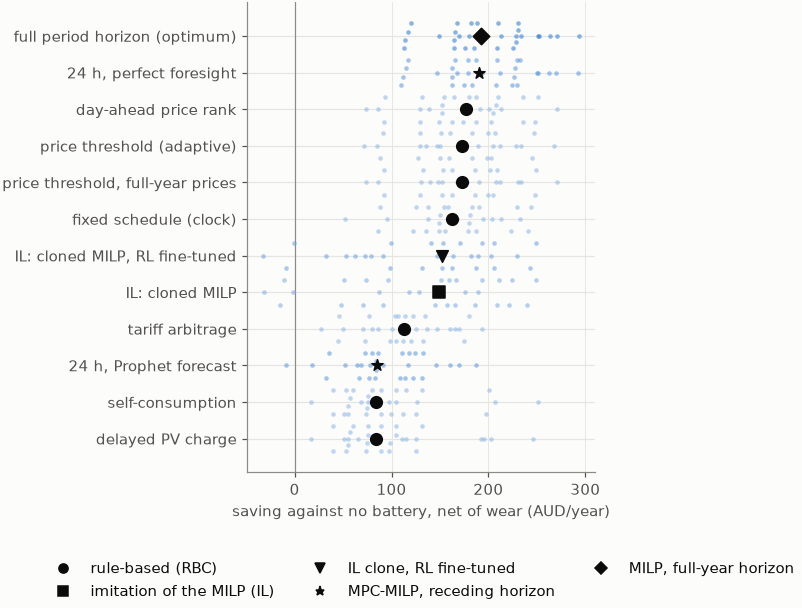

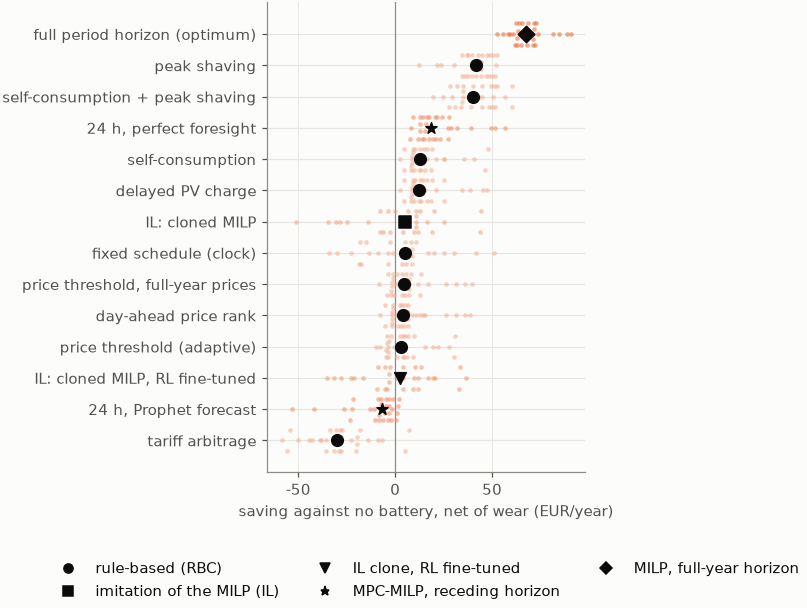

                      saving_operating  wear_eur  saving_annual_net    efc
arm    controller                                                         
AU_H24 bc_dqn_fc_h24             204.5      70.9              133.6  170.2
       bc_fc_h24                 199.1      69.2              129.9  166.1
SI_H24 bc_dqn_fc_h24              44.7      43.3                1.4  104.0
       bc_fc_h24                  50.4      48.5                1.9  116.4


In [2]:
# NET OF WEAR, which is the study's own axis and not a detail: these
# controllers cycle about twice as hard as self-consumption, so a gross saving
# flatters them by 40-70 EUR/a and, on SI, by more than the saving itself.
# One figure per tariff -- at \textwidth a shared row gives each ranking 3.5 in
# for eleven wrapped controller names.
for arm in hs.REFERENCE_ARM.values():
    tariff = hs.arm_tariff(arm)
    sub = long[(long.arm == arm) & (long.controller != "no_battery")]
    order = (sub.groupby("controller")["saving_annual_net"].median()
             .sort_values().index.tolist())
    fig, ax = plt.subplots(figsize=pf.figsize(ratio=0.80))
    for row, c in enumerate(order):
        v = sub.loc[sub.controller == c, "saving_annual_net"].to_numpy()
        ax.scatter(v, row + fs.beeswarm(v), s=9, alpha=0.55, linewidths=0,
                   color=fs.ctrl_color(tariff, c), zorder=2)
        ax.scatter([np.median(v)], [row], marker=fs.ctrl_marker(c), s=58,
                   color=INK, zorder=3)
    ax.axvline(0, color=MUTED, lw=0.8, zorder=1)
    ax.set_yticks(range(len(order)))
    ax.set_yticklabels([fs.tick_label(c, LABEL) for c in order])
    ax.grid(axis="x", color=pf.GRID, lw=0.6)
    ax.set_axisbelow(True)
    fams = [f for f in ("reference", "RBC", "IL", "RL", "IL+RL", "MPC", "MILP")
            if any(fs.ctrl_family(c) == f for c in order)]
    pf.key_legend(ax, [Line2D([], [], marker=fs.FAMILY_MARKER[f], color=INK,
                              ls="none", ms=6, label=fs.FAMILY_LABEL[f])
                       for f in fams], where="below", ncol=3)
    finish(ax, title=f"{tariff}: saving net of wear, 30 households",
           xlabel=f"saving against no battery, net of wear "
                  f"({hs.money(tariff, 'year')})", ylabel="", xfmt=PLAIN)
    pf.show(fig, f"rl_ranking_{tariff.lower()}")

print(long[long.controller.isin(["bc_fc_h24", "bc_dqn_fc_h24"])]
      .groupby(["arm", "controller"])[["saving_operating", "wear_eur",
                                       "saving_annual_net", "efc"]]
      .mean().round(1).to_string())

## 2. What each piece of information is worth

The question the study exists to ask, put to the learned controllers. Every row
is a **within-household** difference between two observation contracts — same
roof, same load, same contract, same battery, same settlement, same net-of-wear
accounting — so it prices the *information*, not the households carrying it.
Wilcoxon through `hems_study.paired_comparison`, the same statistic the MILP
arms are scored by, then **Holm-corrected** over the six questions per method.

Filled marker = significant after correction. The result:

- **AU: only perfect foresight separates from zero** (+5.3 / +13.0 / +11.2
  AUD/a for IL / IL+RL / RL, p ≤ 0.0001, 23–27 of 30 households).
- **SI: nothing separates from zero at all**, foresight included.
- An achievable day-ahead forecast, a perfect roof on top of a real load model,
  and every horizon step straddle zero on **both** tariffs.

This is the same conclusion the forecast study reaches from the other direction
— Prophet losing to seasonal-naive — reached by a different controller family.
The honest headline is negative: *the forecast worth having is the one you
cannot buy, and even that only pays on the tariff with a price spread wide
enough to arbitrage.*

> Read on the **gross** bill instead, SI foresight would have looked significant
> (p 0.003 for IL) and AU's price-feature ablation would have looked like a
> finding (p 0.020). Neither survives wear pricing and Holm correction. Both are
> recorded here as the reason the net axis is the one used.

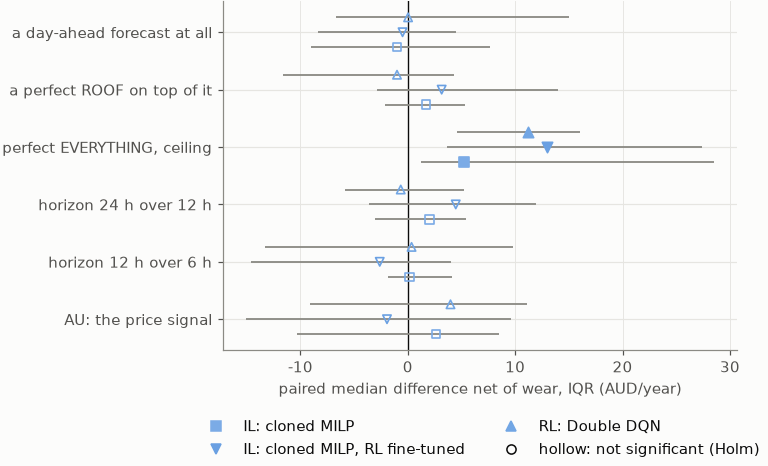

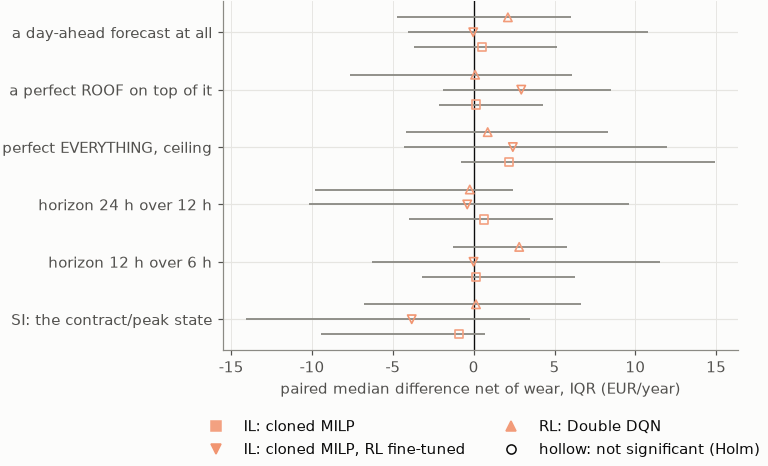


significant after Holm correction:
tariff method                    question  median  wins  p_holm
    AU     bc perfect EVERYTHING, ceiling  5.2731    23  0.0001
    AU bc_dqn perfect EVERYTHING, ceiling 13.0092    26  0.0000
    AU    dqn perfect EVERYTHING, ceiling 11.2110    27  0.0000


In [3]:
# Each row is a WITHIN-household difference between two observation contracts:
# same roof, same load, same contract, same battery, same settlement, and the
# same net-of-wear accounting as the ranking above. Holm over the six questions
# asked of each method -- at six tries an unadjusted 5 % manufactures a finding
# about a quarter of the time.
METHOD_OFFSET = {"bc": +0.26, "bc_dqn": 0.0, "dqn": -0.26}
voi = []
for tariff in ("AU", "SI"):
    sub = rl[rl.tariff == tariff]
    qs = [q for q in rb.VOI_QUESTIONS
          if {q[1], q[2]} <= set(sub.variant.unique())]
    fig, ax = plt.subplots(figsize=pf.figsize(ratio=0.62))
    for method in ("bc", "bc_dqn", "dqn"):
        wide = sub[sub.method == method].pivot(index="ident", columns="variant",
                                               values="net")
        stats = [hs.paired_comparison(wide, rich, poor) for _, rich, poor in qs]
        adj = rb.holm([s["p_value"] for s in stats])
        for row, (q, s, a) in enumerate(zip(qs, stats, adj)):
            y = row + METHOD_OFFSET[method]
            ax.plot([s["q1_diff"], s["q3_diff"]], [y, y], color=MUTED, lw=1.2,
                    zorder=2, solid_capstyle="butt")
            sig = a == a and a < 0.05
            ax.scatter([s["median_diff"]], [y], s=46 if sig else 30,
                       marker=fs.FAMILY_MARKER[hs.LEARNED_ALGORITHM[method][0]],
                       color=fs.ctrl_color(tariff, method) if sig else "none",
                       edgecolors=fs.ctrl_color(tariff, method),
                       linewidths=1.1, zorder=3)
            voi.append({"tariff": tariff, "method": method,
                        "question": q[0].split("(")[0].strip(),
                        "median": s["median_diff"], "wins": s["n_a_greater"],
                        "p_holm": a})
    ax.axvline(0, color=INK, lw=0.9, zorder=1)
    ax.set_yticks(range(len(qs)))
    ax.set_yticklabels([q[0].split("(")[0].strip() for q in qs])
    ax.invert_yaxis()
    ax.grid(axis="x", color=pf.GRID, lw=0.6)
    ax.set_axisbelow(True)
    pf.key_legend(ax, [Line2D([], [], marker=fs.FAMILY_MARKER[
        hs.LEARNED_ALGORITHM[m][0]], color=fs.ctrl_color(tariff, m), ls="none",
        ms=6, label=hs.LEARNED_ALGORITHM[m][1]) for m in ("bc", "bc_dqn", "dqn")]
        + [Line2D([], [], marker="o", mfc="none", mec=INK, color=INK, ls="none",
                  ms=6, label="hollow: not significant (Holm)")],
        where="below", ncol=2)
    finish(ax, title=f"{tariff}: what each piece of information is worth",
           xlabel=f"paired median difference net of wear, IQR "
                  f"({hs.money(tariff, 'year')})", ylabel="", xfmt=PLAIN)
    pf.show(fig, f"rl_value_of_information_{tariff.lower()}")

voi = pd.DataFrame(voi)
print("\nsignificant after Holm correction:")
print(voi[voi.p_holm < 0.05].round(4).to_string(index=False)
      if (voi.p_holm < 0.05).any() else "  (none)")

## 3. Imitation against reinforcement

Two readings, and they disagree — which is the interesting part:

- **On the gross bill**, cloning wins outright: SI `bc` beats `dqn` on 29 of 30
  households, p < 1e-4.
- **Net of wear they are indistinguishable** (SI median −2.1, p = 0.76). The
  clone cycles 116 EFC/a against the DQN's ~75 and pays the difference back in
  pack life.

So reinforcement's timidity on the energy bill is, in part, wear avoidance the
bill alone gives it no credit for. The practical reading is not "IL beats RL"
but "IL extracts more from the tariff and spends more of the pack doing it", and
once the pack is priced the choice between them is a wash on this battery.

  AU dqn     - bc: median    +2.5, 16/30 households, p=0.1294
  AU bc_dqn  - bc: median    -0.1, 15/30 households, p=0.6554


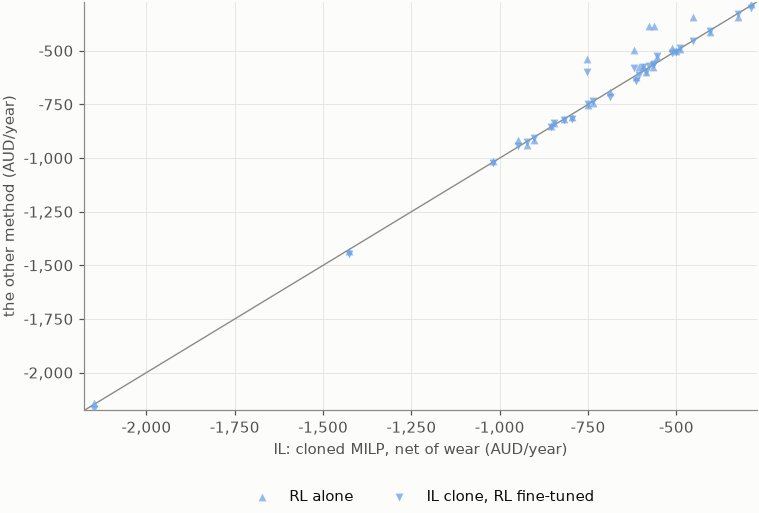

  SI dqn     - bc: median    -2.1, 13/30 households, p=0.7611
  SI bc_dqn  - bc: median    -0.2, 14/30 households, p=0.7303


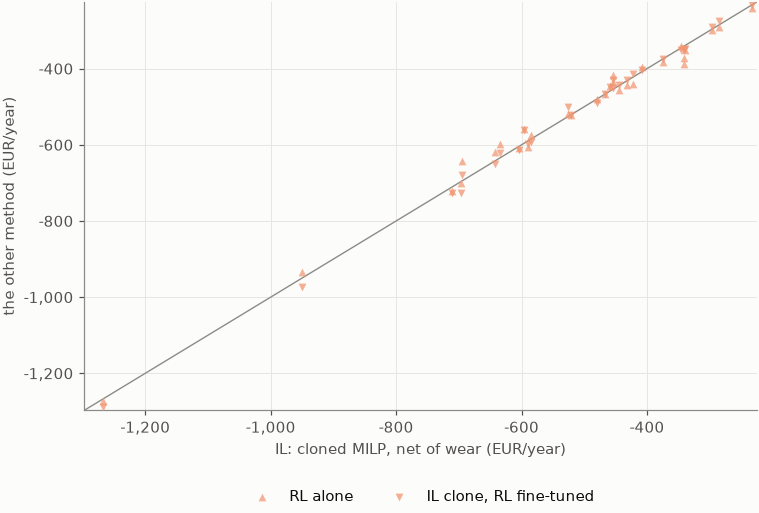

In [4]:
# Paired, on the y=x line, because the question is per household -- "was this
# household better cloned or reinforced?" -- not which mean is larger.
#
# ON THE GROSS BILL the clone wins outright: SI `bc` beats `dqn` on 29 of 30
# households (p < 1e-4). NET OF WEAR the two are indistinguishable, because
# the clone cycles 116 EFC/a against the DQN's ~75 and pays for the
# difference. Reinforcement's timidity on the energy bill is, in part,
# wear avoidance that the bill alone does not credit it for -- which is the
# whole reason this figure is drawn on the net axis.
for tariff in ("AU", "SI"):
    wide = (rl[(rl.tariff == tariff) & (rl.variant == DEPLOYABLE)]
            .pivot(index="ident", columns="method", values="net"))
    fig, ax = plt.subplots(figsize=pf.figsize(ratio=0.68))
    lim = [wide.min().min() - 8, wide.max().max() + 8]
    ax.plot(lim, lim, color=MUTED, lw=0.9, zorder=1)
    for other, marker, lab in (("dqn", "^", "RL alone"),
                               ("bc_dqn", "v", "IL clone, RL fine-tuned")):
        ax.scatter(wide["bc"], wide[other], s=26, marker=marker, alpha=0.75,
                   linewidths=0, color=fs.ctrl_color(tariff, other), zorder=3,
                   label=lab)
        r = hs.paired_comparison(wide, other, "bc")
        print(f"  {tariff} {other:7s} - bc: median {r['median_diff']:+7.1f}, "
              f"{r['n_a_greater']:2d}/{r['n']} households, p={r['p_value']:.4f}")
    ax.set_xlim(lim)
    ax.set_ylim(lim)
    ax.grid(color=pf.GRID, lw=0.6)
    ax.set_axisbelow(True)
    pf.key_legend(ax, ax.get_legend_handles_labels()[0], where="below", ncol=2)
    finish(ax, title=f"{tariff}: imitation against reinforcement, net of wear",
           xlabel=f"IL: cloned MILP, net of wear ({hs.money(tariff, 'year')})",
           ylabel=f"the other method ({hs.money(tariff, 'year')})",
           xfmt=PLAIN, yfmt=PLAIN)
    pf.show(fig, f"rl_imitation_vs_reinforcement_{tariff.lower()}")

## 4. Did the training actually settle?

A saving from a model still improving when the budget ran out is a floor, not a
measurement, so this is checked rather than asserted. Each thin line is one
household's **best-so-far** validation cost, normalised to its own range — raw
EUR would stack thirty curves at thirty heights and show the spread of the
sample instead of the shape of the learning.

Two numbers settle it: **840/840 runs met the early-stop rule**, and the share of
total improvement arriving in the final quarter is ≈0 almost everywhere. The 40
runs that had *not* settled at 500k steps were re-trained at 1M; that moved them
by a median of −1.2 EUR/a with 23 improved and 17 worsened (Wilcoxon p = 0.26)
— **no systematic effect**, so the budget was not truncating the answers.

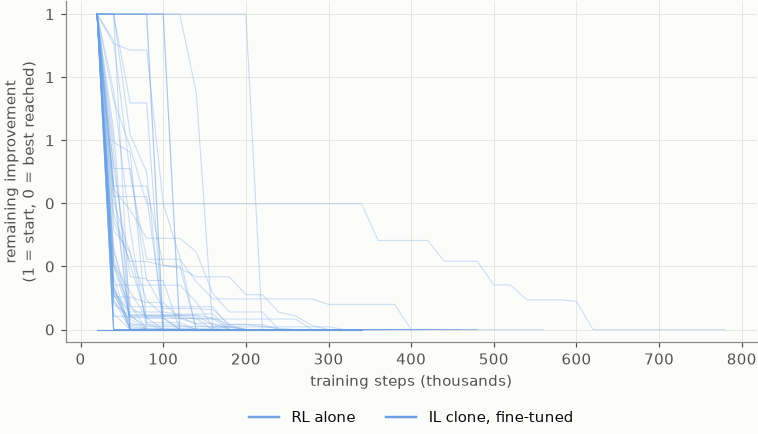

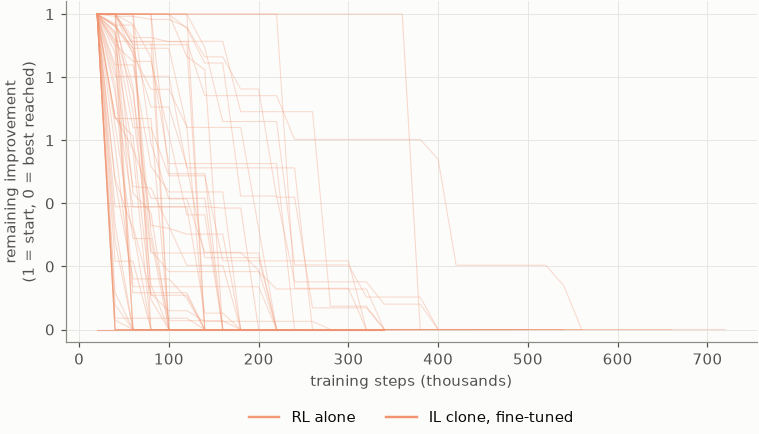


converged by the early-stop rule: 840/840
share of improvement in the final quarter, by tariff and method:
                 mean  median     max
tariff method                        
AU     bc_dqn  0.0000     0.0  0.0000
       dqn     0.0004     0.0  0.0944
SI     bc_dqn  0.0000     0.0  0.0000
       dqn     0.0028     0.0  0.1421


In [5]:
def val_traces(tariff, variant, method):
    """(steps, validation cost) for every household's training run."""
    d = Path("rl_models") / tariff / f"{variant}__{method}"
    out = []
    for f in sorted(d.glob("*.pt.history.json")):
        h = json.load(open(f)).get("dqn")
        if h and h.get("val_step"):
            out.append((np.asarray(h["val_step"]),
                        np.asarray(h["val_cost_closed"], dtype=float)))
    return out

# Drawn as the RUNNING BEST: the raw validation cost is noisy between
# evaluations, and what the early stop acts on -- and what the kept weights
# are -- is the best so far, not the last.
for tariff in ("AU", "SI"):
    fig, ax = plt.subplots(figsize=pf.figsize(ratio=0.58))
    for method, lab in (("dqn", "RL alone"), ("bc_dqn", "IL clone, fine-tuned")):
        col = fs.ctrl_color(tariff, method)
        for steps, v in val_traces(tariff, DEPLOYABLE, method):
            best = np.minimum.accumulate(v)
            # Each household on its own scale: the bills differ two-fold, so
            # raw EUR would stack thirty curves at thirty heights and show the
            # spread of the sample instead of the shape of the learning.
            span = best[0] - best[-1]
            ax.plot(steps / 1000.0, (best - best[-1]) / span if span > 1e-9
                    else np.zeros_like(best), color=col, lw=0.7, alpha=0.35,
                    zorder=2)
        ax.plot([], [], color=col, lw=1.6, label=lab)
    ax.set_ylim(-0.04, 1.04)
    ax.grid(color=pf.GRID, lw=0.6)
    ax.set_axisbelow(True)
    pf.key_legend(ax, ax.get_legend_handles_labels()[0], where="below", ncol=2)
    finish(ax, title=f"{tariff}: every training run, best-so-far validation",
           xlabel="training steps (thousands)",
           ylabel="remaining improvement\n(1 = start, 0 = best reached)",
           yfmt=PLAIN, xfmt=PLAIN)
    pf.show(fig, f"rl_convergence_{tariff.lower()}")

learned_conv = conv[conv.method.isin(["dqn", "bc_dqn"])]
print(f"\nconverged by the early-stop rule: "
      f"{int(learned_conv.converged.fillna(False).astype(bool).sum())}"
      f"/{len(learned_conv)}")
print("share of improvement in the final quarter, by tariff and method:")
print(learned_conv.groupby(["tariff", "method"])["improvement_tail"]
      .agg(["mean", "median", "max"]).round(4).to_string())

## 5. Copying the optimum better is not the same as saving more

The clone is scored on two different things and they are not the same thing: how
often it picks the MILP's action, and what its own year costs net of wear. A
reactive map cannot express a plan, so the two come apart — which is why
held-out agreement is a training diagnostic and never the objective.

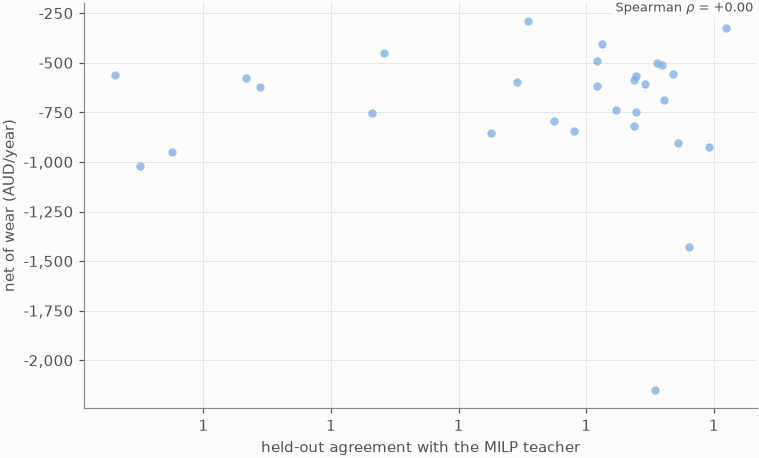

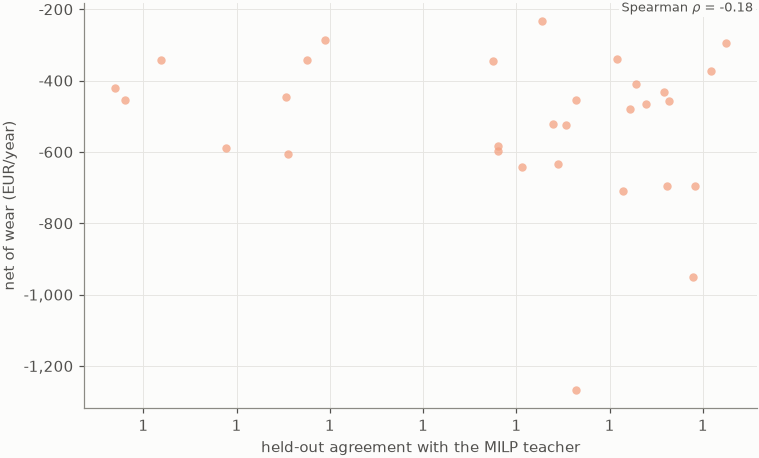

In [6]:
# The clone is scored on two different things, and they are not the same
# thing: how often it picks the MILP's action, and what its own year costs. A
# reactive map cannot express a plan, so the two come apart -- which is why
# agreement is a training diagnostic and never the objective.
agree = (conv[conv.method == "bc"][["tariff", "variant", "ident", "bc_agreement"]]
         .merge(rl[rl.method == "bc"][["tariff", "variant", "ident", "net"]],
                on=["tariff", "variant", "ident"]))
for tariff in ("AU", "SI"):
    a = agree[(agree.tariff == tariff) & (agree.variant == DEPLOYABLE)]
    fig, ax = plt.subplots(figsize=pf.figsize(ratio=0.62))
    ax.scatter(a.bc_agreement, a.net, s=30, alpha=0.75, linewidths=0,
               color=fs.ctrl_color(tariff, "bc"), zorder=3)
    rho = a[["bc_agreement", "net"]].corr(method="spearman").iloc[0, 1]
    pf.edge_label(ax, a.net.max(), f"Spearman $\\rho$ = {rho:+.2f}", side="right")
    ax.grid(color=pf.GRID, lw=0.6)
    ax.set_axisbelow(True)
    finish(ax, title=f"{tariff}: copying the optimum better is not saving more",
           xlabel="held-out agreement with the MILP teacher",
           ylabel=f"net of wear ({hs.money(tariff, 'year')})",
           xfmt=PLAIN, yfmt=PLAIN)
    pf.show(fig, f"rl_teacher_agreement_{tariff.lower()}")

## 6. What this does and does not establish

**Does.** On AU, learned controllers are a genuine alternative to forecast-driven
MPC on the study's own net-of-wear axis: 130–134 AUD/a against the MPC-MILP
arm's 94, at one forward pass per interval instead of an LP solve. Training
convergence is confirmed and shown insensitive to a doubled budget. Perfect
foresight is worth something on AU and is the only information that is.

**Does not.**

1. **The hyperparameters are untuned.** γ was A/B'd once on one household
   (0.99→0.997); `n_step=8`, `bc_reg=1.0`, `reward_scale=20` were reasoned about
   and never searched; `hidden`, `lr`, `batch`, `episode_days` are defaults. The
   step changes during development came from **bug fixes** — a warm start
   destroyed by TD rescaling, an n-step return biased by ε-random continuations,
   a ratchet peak seeded at zero — not from tuning. A single-household A/B sits
   inside the noise floor: between-variant spread is ~10 EUR against a ~63 EUR
   household spread on AU. `tune_rules.py` and `tune_prophet` are this repo's
   pattern for doing it properly and `optuna` is already a dependency; the
   obvious next step is a search over the panel, scored net of wear.
2. **SI is not solved.** These controllers cycle their way to ≈0 net there. The
   wear term is in the training reward but is evidently too light against a
   capacity charge that rewards one well-timed shave a month; a reward that
   charged cycles at the pack rate *and* credited the contract reduction
   directly is the experiment that has not been run.
3. **One seed per run.** Run-to-run spread in the budget test reached 52 EUR on
   individual households, so per-household numbers are noisy even where the
   paired medians are not.
4. **`truth_h24` is a diagnostic**, like `price_oracle`. It is the ceiling, not
   an option.